In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Reshape, BatchNormalization, Activation, LeakyReLU, UpSampling2D, Conv2D

# 모델 이름을 generator로 정하고 Sequential() 함수를 호출
generator = Sequential()
generator.add(Dense(128*7*7, input_dim=100, activation=LeakyReLU(0.2)))
generator.add(BatchNormalization())
generator.add(Reshape((7, 7, 128)))
generator.add(UpSampling2D())
generator.add(Conv2D(64, kernel_size=5, padding='same'))
generator.add(BatchNormalization())
generator.add(Activation(LeakyReLU(0.2)))
generator.add(UpSampling2D())
generator.add(Conv2D(1, kernel_size=5, padding='same', activation='tanh'))

In [2]:
from tensorflow.keras.layers import Flatten, Dropout

# 모델 이름을 dicriminator로 정하고 Sequential() 함수를 호출한다.
discriminator = Sequential()
discriminator.add(Conv2D(64, kernel_size=5, strides=2, input_shape=(28, 28, 1), padding='same'))
discriminator.add(Activation(LeakyReLU(0.2)))
discriminator.add(Dropout(0.3))
discriminator.add(Conv2D(128, kernel_size=5, strides=2, padding='same'))
discriminator.add(Activation(LeakyReLU(0.2)))
discriminator.add(Dropout(0.3))
discriminator.add(Flatten())
discriminator.add(Dense(1, activation='sigmoid'))
discriminator.compile(loss='binary_crossentropy', optimizer='adam')
discriminator.trainable = False

생성자와 판별자를 연결시키고 학습을 진행한다.  
이때 생성자와 판별자를 연결시킨다는 것은 생성자에서 나온 출력을 판별자에 넣어서 진위 여부를 판별하게 만든다는 의미이다.

생성자 G()에 입력 값 input을 넣은 결과는 G(input)이다. 이것을 판별자 D()에 넣은 결과는 D(G(input))이 된다. 생성자는 D(G(input))이 참(1)이라고 주장하지만, 판별자는 실제 데이터인 x로 만든 D(x)만이 참이라고 여긴다. 그리다 학습이 진행되고 너무나 유사해진 D(G(input))과 D(x)를 판별자가 더는 구별하지 못하게 되어 정확도가 0.5에 가까워질 때, 비로소 생성자는 자신의 역할을 다하게 되어 학습은 종료된다.

코드로 표현하면 다음과 같다.

```
ginput = Input(shape=(100,)) ··· 1
dis_output = discriminator(generator(ginput)) ···2
gan = Model(ginput, dis_output) ···3
gan.compile(loss='binary_crossentropy', optimizer='adam') ···4
```

랜덤한 100개의 벡터를 케라스 Input() 함수에 집어넣어 생성자에 입력할 ginput을 만드는 과정이다.

```
ginput = Input(shape=(100,))
```



생성자 모델 generator()에 ginput을 입력한다.  
판별자는 이 입력 값을 가지고 참과 거짓을 판별하는데, 그 결과 dis_output이다.

```
dis_output = discriminator(generator(ginput))
```



생성자 Model() 함수를 이용해 ginput 값과 gis_output 값을 넣어 gan이라는 새로운 모델을 만든다.


```
gan = Model(ginput, dis_output)
```



참과 거짓을 구분하는 이진 로스 함수(binary_crossentropy)와 최적화 함수(adam)를 사용해 gan 모델을 컴파일한다.

```
gan.compile(loss='binary_crossentropy', optimizer='adam')
```



In [3]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input

ginput = Input(shape=(100,))
dis_output = discriminator(generator(ginput))
gan = Model(ginput, dis_output)
gan.compile(loss='binary_crossentropy', optimizer='adam')

gan_train() 함수를 사용해 학습을 진행해본다.  
파라미터는 epoch, batch_size, 그리고 중간 과정을 저장할 때 몇 번마다 한 번씩 저장할지 정하는 saving_interval이 있다.

In [4]:
# 실행 함수를 선언한다.
def gan_train(epoch, batch_size, saving_interval):

# MNIST 데이터 불러오기
    # MNIST 데이터를 불러와 이용한다. 단, 테스트 과정은 필요 없고
    # 이미지만 사용할 것이기 때문에 X_train만 호출한다.
    (X_train, _), (_, _) = mnist.load_data()

    # 가로 28픽셀, 세로 28픽셀이고 흑백이므로 1을 설정한다.
    X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32')

    # 0~255 사이 픽셀 값에서 127.5를 뺀 후 127.5로 나누면 -1~1 사이 값으로 바뀐다.
    X_train = (X_train - 127.5) / 127.5

tanh() 함수를 사용한 이유는 지금 불러올 이 데이터의 픽셀 값을 -1~1사이의 값으로 지정하기 위해서이다.

batch_size는 한 번에 몇 개의 실제 이미지와 몇 개의 가장 이미지를 판별자에 넣을지 결정하는 변수이다.  
실제 이미지를 입력했으므로 '모두 참(1)'이라는 레이블을 붙인다.



```
true = np.ones((batch_size, 1)) ··· 1
idx = np.random.randint(0, X_train.shape[0], batch_size) ··· 2
imgs = X_train[idx] ··· 3
d_loss_real = discriminator.train_on_batch(imgs, true) ··· 4
```




'모두 참(1)'이라는 레이블 값을 가진 배열을 만든다.
```
true = np.ones((batch_size, 1))
```


넘파이 라이브러리의 random() 함수를 사용해서 실제 이미지를 랜덤하게 불러온다.  
0부터 X_train 개수 사이의 숫자를 랜덤하게 batch_size만큼 반복해서 가져오게 했다.
```
idx = np.random.randint(0, X_train.shape[0], batch_size)
```




선택된 숫자에 해당하는 이미지를 불러온다.
```
imgs = X_train[idx]
```



판별자 모델에 train_on_batch() 함수를 써서 판별을 시작한다. train(x, y) 함수는 입력 값(x)과 레이블(y)을 받아서 딱 한 번 학습을 실시해 모델을 업데이트한다.  
만든 이미지를 x, 만든 배열을 y에 놓아 준비를 마친다.

```
d_loss_real = discriminator.train_on_batch(imgs, true)
```



가상의 이미지는 '모두 거짓(0)'이라는 레이블을 준비해 붙인다.  
학습이 반복될수록 가짜라는 레이블을 붙인 이미지들에 대한 예측 결과가 거짓으로 나온다.

```
fake = np.zeros((batch_size, 1)) ···1
noise = np.random.normal(0, 1, batch_size, 100) ···2
gen_imgs = generator.predict(noise) ···3
d_loss_fake = discriminator.train_on_batch(gen_imgs, fake) ···4
```



'모두 거짓(0)'이라는 레이블 값을 가진 열을 batch_size 길이만큼 만든다.

```
fake = np.zeros((batch_size, 1)) ···1
```



생성자에 집어넣을 가상 이미지를 만든다. 정수가 아니기 때문에 np.random.normal() 함수를 사용한다.  
(batch_size, 100)은 batch_size만큼 100열을 뽑으라는 의미이다.

```
noise = np.random.normal(0, 1, batch_size, 100)
```



만들어진 값이 생성자에 들어가고 결괏값이 gen_img로 저장된다.

```
gen_imgs = generator.predict(noise)
```



fake는 '모두 거짓(0)'이라는 레이블이 붙는다. 이대로 판별자로 입력된다.

```
d_loss_fake = discriminator.train_on_batch(gen_imgs, fake)
```



실제 이미지를 넣은 d_loss_real과 가상 이미지를 입력한 d_loss_fake가 판별자 안에서 번갈아 가며 진위를 판단하기 시작한다.

```
# d_loss_real, d_loss_fake 값을 더해 둘로 나눈 평균이 바로 판별자의 오차이다.
d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)
```



판별자와 생성자를 연결해서 만든 gen 모델을 이용해 생성자와 오차. g_loss를 구한다.  
train_on_batch() 함수와 gen_imgs를 사용한다. 생성자의 레이블은 무조건 참(1)이라 해놓고 판별자로 넘긴다. 따라서 이번에도 앞서 만든 true 배열로 레이블을 붙인다.

```
g_loss = gan.train_on_batch(noise, true)
```

그리고 학습이 진행되는 동안 생성자와 판별자의 오차를 출력한다.


```
print('epoch:%d' % i, 'd_loss:%.4f" % d_loss, 'g_loss:%.4f' % g_loss)
```



실습| GAN 모델 만들기

In [5]:
%cd "/content/drive/MyDrive/Colab Notebooks/모두의 딥러닝/딥러닝 활용하기/세상에 없는 얼굴 GAN,  오토인코더"

/content/drive/MyDrive/Colab Notebooks/모두의 딥러닝/딥러닝 활용하기/세상에 없는 얼굴 GAN,  오토인코더


Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 100)]             0         
                                                                 
 sequential_2 (Sequential)   (None, 28, 28, 1)         865281    
                                                                 
 sequential_3 (Sequential)   (None, 1)                 212865    
                                                                 
Total params: 1078146 (4.11 MB)
Trainable params: 852609 (3.25 MB)
Non-trainable params: 225537 (881.00 KB)
_________________________________________________________________
1/1 [==============================] - 0s 346ms/step
epoch:0 dloss:0.7026 g_loss:0.6778
1/1 [==============================] - 0s 151ms/step
epoch:1 dloss:0.4866 g_loss:0.4071
1/1 [==============================] - 0s 160ms/step
epoch:2 dloss:0.5380 g_loss:0.1952
1/1 [============

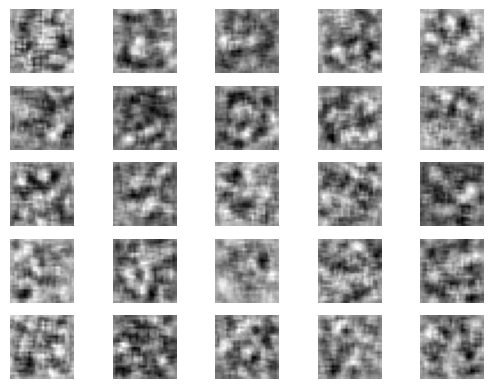

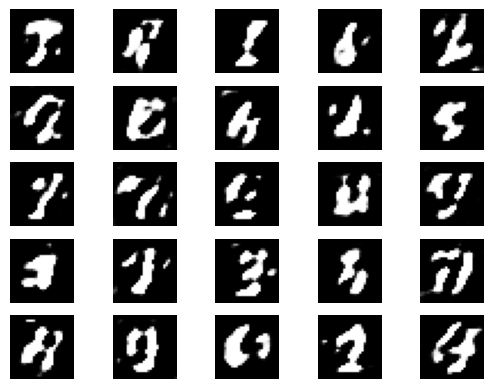

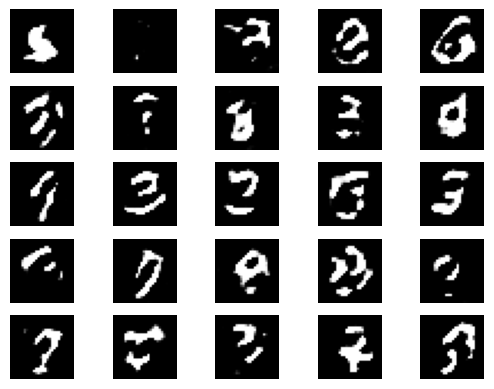

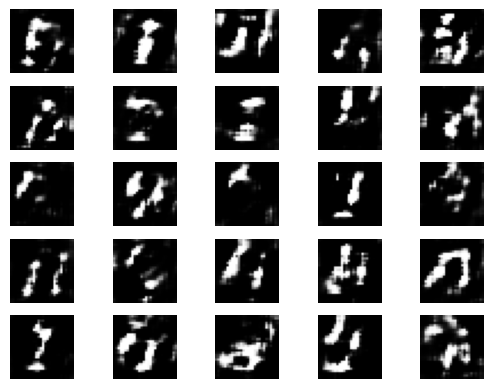

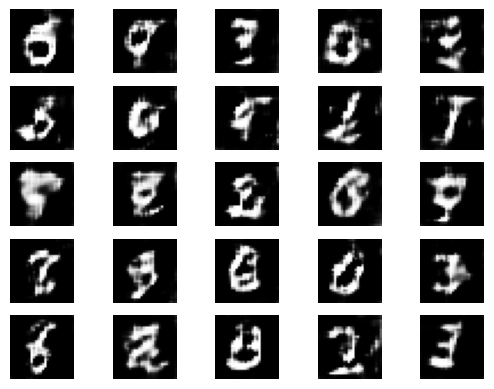

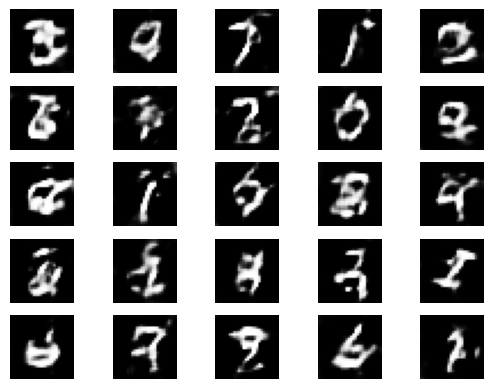

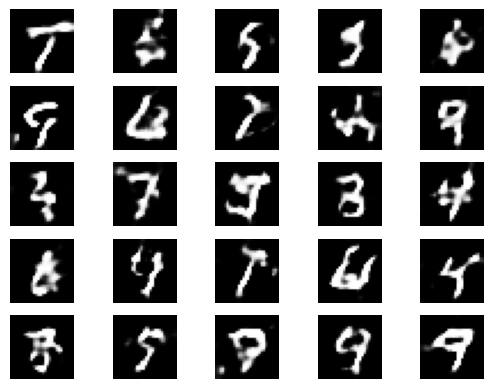

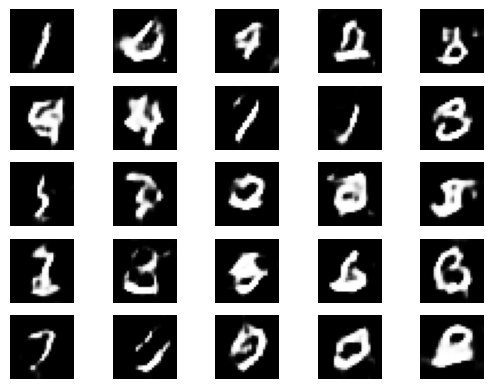

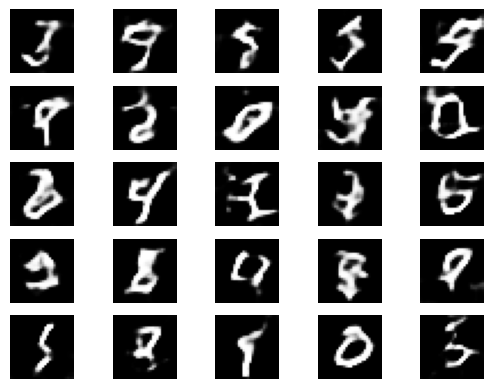

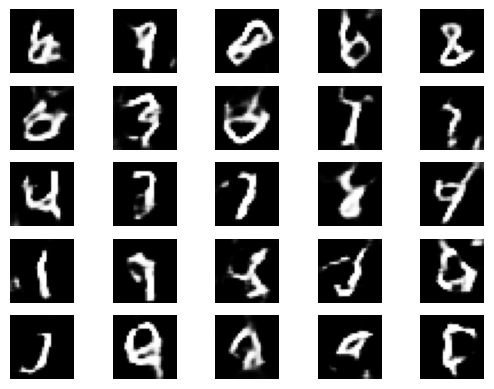

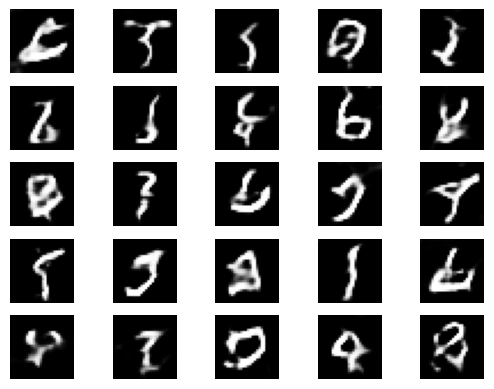

In [6]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense, Reshape, Flatten, Dropout
from tensorflow.keras.layers import BatchNormalization, Activation, LeakyReLU, UpSampling2D, Conv2D
from tensorflow.keras.models import Sequential, Model

import numpy as np
import matplotlib.pyplot as plt

# 생성자 모델을 만든다.
generator = Sequential()
generator.add(Dense(128*7*7, input_dim=100, activation=LeakyReLU(0.2)))
generator.add(BatchNormalization())
generator.add(Reshape((7, 7, 128)))
generator.add(UpSampling2D())
generator.add(Conv2D(64, kernel_size=5, padding='same'))
generator.add(BatchNormalization())
generator.add(Activation(LeakyReLU(0.2)))
generator.add(UpSampling2D())
generator.add(Conv2D(1, kernel_size=5, padding='same', activation='tanh'))

# 판별자 모델을 만든다.
discriminator = Sequential()
discriminator.add(Conv2D(64, kernel_size=5, strides=2,
                         input_shape=(28, 28, 1), padding='same'))
discriminator.add(Activation(LeakyReLU(0.2)))
discriminator.add(Dropout(0.3))
discriminator.add(Conv2D(128, kernel_size=5, strides=2, padding='same'))
discriminator.add(Activation(LeakyReLU(0.2)))
discriminator.add(Dropout(0.3))
discriminator.add(Flatten())
discriminator.add(Dense(1, activation='sigmoid'))
discriminator.compile(loss='binary_crossentropy', optimizer='adam')
discriminator.trainable = False

# 생성자와 판별자 모델을 연결시키는 gan 모델을 만든다.
ginput = Input(shape=(100,))
dis_output = discriminator(generator(ginput))
gan = Model(ginput, dis_output)
gan.compile(loss='binary_crossentropy', optimizer='adam')
gan.summary()

# 신경망을 실행시키는 함수를 만든다.
def gan_train(epoch, batch_size, saving_interval):

# MNIST 데이터 불러오기
    # 앞서 불러온 MNIST를 다시 이용한다. 테스트 과정은 필요 없고
    # 이미지만 사용할 것이기 때문에 X_train만 호출한다.
    (X_train, _), (_, _) = mnist.load_data()
    X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32')

    # 127.5를 뺀 후 127.5로 나누어서 -1~1 사이의 값으로 바꾼다.
    X_train = (X_train - 127.5) / 127.5

    true = np.ones((batch_size, 1))
    fake = np.zeros((batch_size, 1))

    for i in range(epoch):
        # 실제 데이터를 판별자에 입력하는 부분이다.
        idx = np.random.randint(0, X_train.shape[0], batch_size)
        img = X_train[idx]
        d_loss_real = discriminator.train_on_batch(img, true)

        # 가상 이미지를 판별자에 입력하는 부분이다.
        noise = np.random.normal(0, 1, (batch_size, 100))
        gen_imgs = generator.predict(noise)
        d_loss_fake = discriminator.train_on_batch(gen_imgs, fake)

        # 판별자와 생성자의 오차를 계산한다.
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)
        g_loss = gan.train_on_batch(noise, true)

        print('epoch:%d' % i, 'dloss:%.4f' % d_loss, 'g_loss:%.4f' % g_loss)

        # 중간 과정을 이미지로 저장하는 부분이다. 정해진 인터벌만큼 학습되면
        # 그때 만든 이미지 gen_images 폴더에 저장하라는 의미이다.
        if i % saving_interval == 0:
            # r, c = 5, 5
            noise = np.random.normal(0, 1, (25, 100))
            gen_imgs = generator.predict(noise)

            # Rescale images 0 - 1
            gen_imgs = 0.5 * gen_imgs + 0.5

            fig, axs =plt.subplots(5, 5)
            count = 0
            for j in range(5):
                for k in range(5):
                    axs[j, k].imshow(gen_imgs[count, :, :, 0], cmap='gray')
                    axs[j, k].axis('off')
                    count += 1
            fig.savefig("gan_images/gan_mnist_%d.png" % i)

# 2000번 반복되고(+1을 하는 것에 주의),
# 배치 크기는 32, 200번마다 결과가 저장된다.
gan_train(2001, 32, 200)